In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk


C:\Users\Lenovo-Pc\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Lenovo-Pc\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
data = pd.read_csv(r'D:\Project - Data Mining\Project\Data-Mining---Predictive-Maintenance-of-CNC-Machines\Local Repository\Data-Mining---Predictive-Maintenance-of-CNC-Machines\Pre-processing\Tool-Wear-forces\final_data_fz.csv')
data.head(5)

,Position,TCond,vc,cat,cont_1,cont_2,Fz
0,92.841818,82.268857,85.86697,-112.833752,-14.818100,0.432755,21.07
1,92.841818,82.268857,85.86697,-112.833752,-14.841330,0.091866,21.07
2,92.841818,82.268857,85.86697,-112.833752,-14.811296,0.455781,21.07
3,92.841818,82.268857,85.86697,-112.833752,-14.799785,0.532965,21.07
4,92.841818,82.268857,85.86697,-112.833752,-14.837682,1.058478,21.07


In [3]:
X = data.iloc[:,0:6]
y = data.iloc[:,-1:7]

In [4]:
X

,Position,TCond,vc,cat,cont_1,cont_2
0,92.841818,82.268857,85.86697,-112.833752,-14.818100,0.432755
1,92.841818,82.268857,85.86697,-112.833752,-14.841330,0.091866
2,92.841818,82.268857,85.86697,-112.833752,-14.811296,0.455781
3,92.841818,82.268857,85.86697,-112.833752,-14.799785,0.532965
4,92.841818,82.268857,85.86697,-112.833752,-14.837682,1.058478
...,...,...,...,...,...,...
607,82.506667,138.648750,85.86697,109.434780,-6.832246,2.885314
608,82.506667,138.648750,85.86697,109.434780,-6.801676,3.266256
609,82.506667,138.648750,85.86697,109.434780,-6.829237,3.665430
610,82.506667,138.648750,85.86697,109.434780,-6.826498,2.459472


In [5]:
y

,Fz
0,21.07
1,21.07
2,21.07
3,21.07
4,21.07
...,...
607,174.90
608,174.90
609,174.90
610,174.90


In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size = 0.25, random_state = 42)
# Train => 60%, Test => 20%, Validation => 20%

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Create a pipeline: StandardScaler + SVR
model = make_pipeline(StandardScaler(), SVR(kernel='rbf', C=100, epsilon=0.1))

# Fit on training data
model.fit(X_train, y_train)

# Predict on validation or test data
y_pred = model.predict(X_val)


C:\Users\Lenovo-Pc\anaconda3\lib\site-packages\sklearn\utils\validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


In [8]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_val)
mse = mean_squared_error(y_val, y_pred)
mse

32.40324387105053

In [9]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mse

21.175046311107774

In [10]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
r2

0.9938303576038816

In [11]:
y_train = y_train.values.ravel() 
y_test = y_test.values.ravel() 
y_val = y_val.values.ravel() 

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)


y_train_pred = y_train_pred.ravel()
y_val_pred = y_val_pred.ravel()
y_test_pred = y_test_pred.ravel()


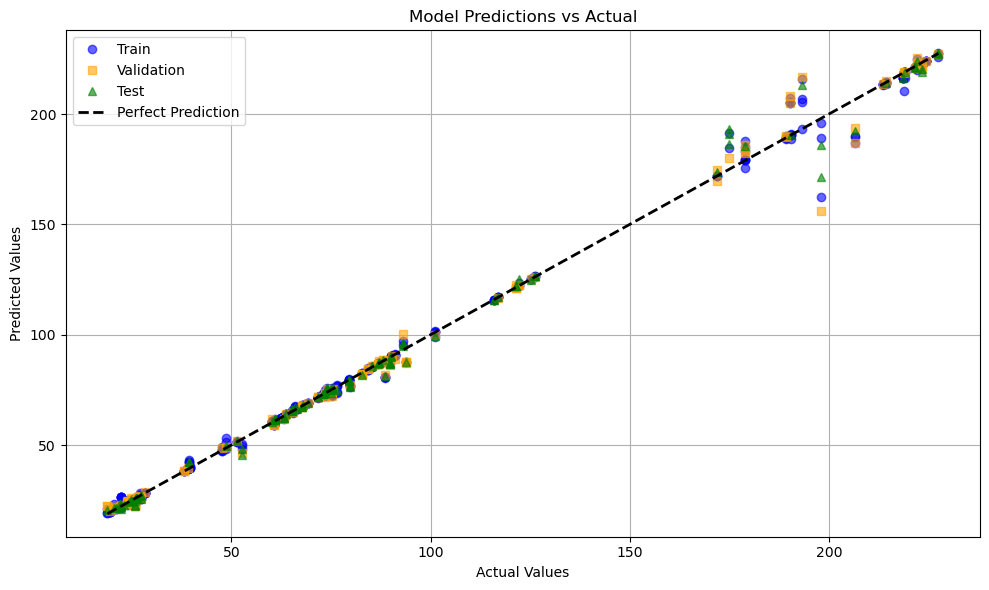

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(y_train, y_train_pred, 'o', label='Train', color='blue', alpha=0.6)
plt.plot(y_val, y_val_pred, 's', label='Validation', color='orange', alpha=0.6)
plt.plot(y_test, y_test_pred, '^', label='Test', color='green', alpha=0.6)

# Reference perfect prediction line
min_val = min(y_train.min(), y_val.min(), y_test.min())
max_val = max(y_train.max(), y_val.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Model Predictions vs Actual')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
y_test

array([ 61.05,  73.61,  68.08, 172.  ,  74.87, 121.5 ,  89.72, 223.4 ,
       190.6 , 126.3 ,  79.43,  63.16,  22.37,  73.5 , 126.3 , 223.4 ,
        87.15,  93.72,  25.94,  21.07,  22.37,  82.71,  52.58,  22.9 ,
       116.9 ,  74.01,  88.58,  27.28, 218.6 ,  69.12,  60.21,  22.11,
        65.19,  79.87,  90.15,  51.42, 179.  ,  25.89,  24.17,  18.87,
       206.6 ,  39.29,  74.01,  25.1 ,  75.26, 174.9 ,  22.37,  71.62,
        67.71,  79.43,  79.55, 121.5 , 221.5 ,  61.05,  86.88,  63.82,
       174.9 ,  74.87,  26.26, 101.2 ,  22.11,  26.26,  27.28, 198.1 ,
        73.01, 214.3 , 227.5 ,  25.76,  79.43,  76.44,  65.19,  85.26,
        75.56, 227.5 ,  65.19,  39.29,  61.05, 198.1 ,  25.9 ,  74.01,
        24.75,  87.15, 125.2 ,  25.94,  27.34,  24.75,  89.72,  79.87,
        65.88,  71.8 , 115.8 ,  74.87,  89.72,  24.75,  25.76, 221.5 ,
        73.01,  89.72,  65.19,  20.51,  93.19,  48.52,  67.71, 174.9 ,
       193.2 ,  63.16,  88.08,  75.56, 115.8 ,  52.58, 222.1 ,  87.15,
      